# Подготовка

In [1]:
!python -V

Python 3.10.12


In [2]:
!where python

/bin/bash: line 1: where: command not found


In [3]:
import sys

print(sys.executable)

/home/ubuntu/rnn-lstm-gru/.venv/bin/python


In [4]:
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# %pip install -r requirements2.txt # на mac

In [ ]:
%pip install -r requirements3.txt # для виртуальной машины

Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install -U torch>=2.0.0 --index-url https://download.pytorch.org/whl/cu121 # для виртуальной машины

Note: you may need to restart the kernel to use updated packages.


In [7]:
import torch

torch.cuda.is_available()

True

# Загрузка и подготовка данных

In [8]:
from datasets import load_dataset

dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

In [9]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [10]:
from sklearn.model_selection import train_test_split

print(type(dataset))

train_load = dataset['train']['text']
val_load = dataset['validation']['text']
test_load = dataset['test']['text']

texts = dataset['train']['text']
train_load, temp_texts = train_test_split(texts, test_size=0.2, random_state=42)
val_load, test_load = train_test_split(temp_texts, test_size=0.5, random_state=42)

# train_load = train_load[:len(train_load) // 10]
# val_load = val_load[:len(val_load) // 10]
# test_load = test_load[:len(test_load) // 10]

print(len(train_load))
print(len(val_load))
print(len(test_load))

<class 'datasets.dataset_dict.DatasetDict'>
29374
3672
3672


In [11]:
import re

def preprocess_text(text: str) -> str:
    
    # приведение к нижнему регистру
    text = text.lower()
    # удаление всех символов, кроме букв, чисел и пробелов
    text = re.sub(r"[^a-zа-яё0-9 ]+", "", text)
    # удаление всех символов, кроме любых букв, чисел и пробелов
    # text = re.sub(r"[^\w ]|_", "", text)
    # удаление дублирующихся пробелов и пробелов в начале и в конце
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [12]:
train_corpus = [preprocess_text(message) for message in train_load if message.strip()]
val_corpus = [preprocess_text(message) for message in val_load if message.strip()]
test_corpus = [preprocess_text(message) for message in test_load if message.strip()]

for line in train_corpus[:3]:
    print(line)

el sol made two more roundtrips for the nots over the next five months while returning to the united states from her last nots sailing in late march 1919 el sol responded to distress calls from scranton a navy troop transport which had a damaged rudder and was disabled el sol came to the aid of the stricken ship which was 900 nautical miles 1 700 km east of new york to attempt to take her under tow during the day on 28 march scranton attempted to run a towline to el sol by sending a launch in the rolling seas but it capsized killing three men ultimately el sol stood by scranton for over 40 hours until minesweeper penguin arrived and took scranton under tow
since 2015 villa s shirt sponsors have been quickbooks previous commercial sponsors have been davenports 1982 83 mita 1983 93 mller 1993 95 ast computer 1995 98 ldv 1998 2000 ntl 2000 02 rover 2002 04 dws investments 2004 06 32redcom 2006 08 fxpro 2010 11 genting casinos 2011 13 dafabet 2013 2015 and intuit quickbooks 2015 since 2016

In [13]:
train_word = [message.split() for message in train_corpus]
val_word = [message.split() for message in val_corpus]
test_word = [message.split() for message in test_corpus]

for line in train_word[:3]:
    print(line)

['el', 'sol', 'made', 'two', 'more', 'roundtrips', 'for', 'the', 'nots', 'over', 'the', 'next', 'five', 'months', 'while', 'returning', 'to', 'the', 'united', 'states', 'from', 'her', 'last', 'nots', 'sailing', 'in', 'late', 'march', '1919', 'el', 'sol', 'responded', 'to', 'distress', 'calls', 'from', 'scranton', 'a', 'navy', 'troop', 'transport', 'which', 'had', 'a', 'damaged', 'rudder', 'and', 'was', 'disabled', 'el', 'sol', 'came', 'to', 'the', 'aid', 'of', 'the', 'stricken', 'ship', 'which', 'was', '900', 'nautical', 'miles', '1', '700', 'km', 'east', 'of', 'new', 'york', 'to', 'attempt', 'to', 'take', 'her', 'under', 'tow', 'during', 'the', 'day', 'on', '28', 'march', 'scranton', 'attempted', 'to', 'run', 'a', 'towline', 'to', 'el', 'sol', 'by', 'sending', 'a', 'launch', 'in', 'the', 'rolling', 'seas', 'but', 'it', 'capsized', 'killing', 'three', 'men', 'ultimately', 'el', 'sol', 'stood', 'by', 'scranton', 'for', 'over', '40', 'hours', 'until', 'minesweeper', 'penguin', 'arrived',

# Кастомный word-токенизатор

In [14]:
from collections import Counter

class WordTokenizer:
    def __init__(self, min_freq=8):

        self.min_freq = min_freq

        self.word2idx = {}
        self.idx2word = {}

        # специальные токены
        self.pad_token = "<PAD>"
        self.unk_token = "<UNK>"

    def fit(self, texts):

        counter = Counter()

        for words in texts:

            # words уже список токенов
            words = [word.lower() for word in words]

            counter.update(words)

        vocab = [self.pad_token, self.unk_token]

        for word, freq in counter.items():
            if freq >= self.min_freq:
                vocab.append(word)

        self.word2idx = {word: idx for idx, word in enumerate(vocab)}

        self.idx2word = {idx: word for word, idx in self.word2idx.items()}

    def encode(self, words, truncation = False, max_length = None):

        words = [word.lower() for word in words]

        tokens = []

        for word in words:
            token_id = self.word2idx.get(word, self.word2idx[self.unk_token])
            tokens.append(token_id)

        if max_length is not None and len(tokens) > max_length:
            if truncation:
                tokens = tokens[:max_length]
            else:
                raise ValueError(f"Слишком много токенов: {len(tokens)} > {max_length}")
        return tokens

    def decode(self, token_ids):

        words = []

        for token_id in token_ids:
            word = self.idx2word.get(token_id, self.unk_token)
            words.append(word)

        return words

    @property
    def vocab_size(self):
        return len(self.word2idx)

In [15]:
word_tokenizer = WordTokenizer(min_freq=5)

word_tokenizer.fit(train_word)
print("Vocabulary size:", word_tokenizer.vocab_size)

Vocabulary size: 18386


In [16]:
train_word_tokens = [word_tokenizer.encode(message) for message in train_word]
val_word_tokens = [word_tokenizer.encode(message) for message in val_word]
test_word_tokens = [word_tokenizer.encode(message) for message in test_word]

In [17]:
text = "the cat sat on the mat".split()
print(text)

tokens = word_tokenizer.encode(text)
print(tokens)

decoded = word_tokenizer.decode(tokens)
print(decoded)

['the', 'cat', 'sat', 'on', 'the', 'mat']
[8, 11005, 6033, 60, 8, 6378]
['the', 'cat', 'sat', 'on', 'the', 'mat']


## Train

In [18]:
print('#ORIGINAL')
for message in train_load[:8]:
    if not message:
        continue
    print(len(message), message, end="")

print('\n#LOWKEY, NO SYMBOL')
for message in train_corpus[:5]:
    print(len(message), message)

print('\n#WORD')
for word in train_word[:3]:
    print(word)

print('\n#WORD (ENCODED)')
for tokens in train_word_tokens[:3]:
    print(tokens)

print('\n#WORD (DECODED)')
for tokens in train_word_tokens[:3]:
    print(word_tokenizer.decode(tokens))

#ORIGINAL
701  El Sol made two more roundtrips for the NOTS over the next five months . While returning to the United States from her last NOTS sailing in late March 1919 , El Sol responded to distress calls from Scranton , a Navy troop transport which had a damaged rudder and was disabled . El Sol came to the aid of the stricken ship , which was 900 nautical miles ( 1 @,@ 700 km ) east of New York , to attempt to take her under tow . During the day on 28 March , Scranton attempted to run a towline to El Sol by sending a launch in the rolling seas , but it capsized , killing three men . Ultimately , El Sol stood by Scranton for over 40 hours until minesweeper Penguin arrived and took Scranton under tow . 
768  Since 2015 Villa 's shirt sponsors have been Quickbooks . Previous commercial sponsors have been Davenports ( 1982 – 83 ) , Mita ( 1983 – 93 ) , Müller ( 1993 – 95 ) , AST Computer ( 1995 – 98 ) , LDV ( 1998 – 2000 ) , NTL ( 2000 – 02 ) , Rover ( 2002 – 04 ) , DWS Investments ( 2

## Validation

In [19]:
print('#ORIGINAL')
for message in val_load[:9]:
    if not message:
        continue
    print(len(message), message, end="")

print('\n#LOWKEY, NO SYMBOL')
for message in val_corpus[:5]:
    print(len(message), message)

print('\n#WORD')
for word in val_word[:3]:
    print(word)

print('\n#WORD (TOKENIZED)')
for tokens in val_word_tokens[:3]:
    print(tokens)

print('\n#WORD (DECODED)')
for tokens in val_word_tokens[:3]:
    print(word_tokenizer.decode(tokens))

#ORIGINAL
240  Mkhedruli ( Georgian : მხედრული ) is the third and current Georgian script . Mkhedruli , literally meaning " cavalry " or " military " , derives from mkhedari ( მხედარი ) meaning " horseman " , " knight " , " warrior " and " cavalier " . 
443  Other important patrons of Polish culture included the Roman Catholic Church and Polish aristocrats , who likewise supported artists and safeguarded Polish heritage ( notable patrons included Cardinal Adam Stefan Sapieha and a former politician , Janusz Radziwiłł ) . Some private publishers , including Stefan Kamieński , Zbigniew Mitzner and the Ossolineum publishing house , paid writers for books that would be delivered after the war . 
182  The noisy miner also produces non @-@ vocal sounds by clicking or snapping its bill , usually during antagonistic encounters with other bird species , or when mobbing a predator . 
16  = = Music = = 
1309  Angelo was forced to help Nicole give birth to a baby boy , George , and she handed him 

## Test

In [20]:
print('#ORIGINAL')
for message in test_load[:10]:
    if not message:
        continue
    print(len(message), message, end="")

print('\n#LOWKEY, NO SYMBOL')
for message in test_corpus[:5]:
    print(len(message), message)

print('\n#WORD')
for word in test_word[:3]:
    print(word)

print('\n#WORD (TOKENIZED)')
for tokens in test_word_tokens[:3]:
    print(tokens)

print('\n#WORD (DECODED)')
for tokens in test_word_tokens[:3]:
    print(word_tokenizer.decode(tokens))

#ORIGINAL
1149  Galveston has been home to many important figures in Texas and U.S. history . During the island 's earliest history it became the domain of Jean Lafitte , the famed pirate and American hero of the War of 1812 . Richard Bache , Jr. who represented Galveston in the Senate of the Second Texas Legislature in 1847 and assisted in drawing up the Constitution of 1845 . He was also the grandson of Benjamin Franklin , one of the Founding Fathers of the United States of America and Deborah Read . In 1886 , the African @-@ American Galveston civil rights leader Norris Wright Cuney rose to become the head of the Texas Republican Party and one of the most important Southern black leaders of the century . Noted portrait and landscape artist Verner Moore White moved from Galveston the day before the 1900 hurricane . While he survived , his studio and much of his portfolio were destroyed . A survivor of the hurricane was the Hollywood director King Vidor , who made his directing debut 

# Разведочный анализ: примеры текстов, посчитайте статистики (число предложений, среднюю длину, распределение длин).

In [21]:
from collections import Counter

def get_avg_message_len(tokenized_messages):
    tokens_count = 0
    for message in tokenized_messages:
        tokens_count += len(message)
    return tokens_count / len(tokenized_messages)

print("Средняя длина:", get_avg_message_len(train_word_tokens))

flat_word_tokens = [token for message in train_word for token in message]

word_freq_top10 = Counter(flat_word_tokens).most_common(10)

print("Топ-10 слов:", word_freq_top10)

Средняя длина: 73.35310185428376
Топ-10 слов: [('the', 104405), ('of', 45647), ('and', 40528), ('in', 35975), ('to', 31566), ('a', 29166), ('was', 16809), ('on', 12052), ('as', 12029), ('s', 11606)]


# Создаем входные и выходные последовательности для предсказания следующего слова

In [22]:
import torch

from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    def __init__(self, texts, tokenizer, seq_len=32, max_length=512):
        self.samples = []
        
        for text in texts:
            tokens = tokenizer.encode(text, truncation=True, max_length=max_length)

            if len(tokens) < seq_len:
                continue

            for i in range(0, len(tokens) - seq_len + 1, seq_len):
                seq = tokens[i:i + seq_len]

                context = seq[:-1]
                target = seq[1:]

                self.samples.append((torch.tensor(context), torch.tensor(target)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

In [23]:
from torch.nn.utils.rnn import pad_sequence

def word_collate_fn(batch):
    x_batch, y_batch = zip(*batch)

    x_batch = pad_sequence(x_batch, batch_first=True, padding_value=word_tokenizer.word2idx["<PAD>"])
    y_batch = pad_sequence(y_batch, batch_first=True, padding_value=-100)

    return x_batch, y_batch

In [24]:
batch_size = 32

train_dataset = TextDataset(train_word, tokenizer=word_tokenizer)
val_dataset = TextDataset(val_word, seq_len=12, tokenizer=word_tokenizer)
test_dataset = TextDataset(test_word, seq_len=12, tokenizer=word_tokenizer)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, collate_fn=word_collate_fn,)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=word_collate_fn,)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=word_collate_fn,)

print(f'Количество батчей в train_dataloader: {len(train_dataloader)}')
print(f'Количество батчей в val_dataloader: {len(val_dataloader)}')
print(f'Количество батчей в test_dataloader: {len(test_dataloader)}')

x_batch, y_batch = next(iter(train_dataloader))

print("\nX shape:", x_batch.shape)
print("Y shape:", y_batch.shape)

print("\nX example:")
print(x_batch[0])
print(x_batch[1])

print("\nY example:")
print(y_batch[0])

print("\nDecoded X:")
print(word_tokenizer.decode(x_batch[0].tolist()))
print(word_tokenizer.decode(x_batch[1].tolist()))

print("\nDecoded Y:")
print(word_tokenizer.decode(y_batch[0][y_batch[0] != -100].tolist()))

Количество батчей в train_dataloader: 1152
Количество батчей в val_dataloader: 436
Количество батчей в test_dataloader: 425

X shape: torch.Size([32, 31])
Y shape: torch.Size([32, 31])

X example:
tensor([ 2,  3,  4,  5,  6,  1,  7,  8,  1,  9,  8, 10, 11, 12, 13, 14, 15,  8,
        16, 17, 18, 19, 20,  1, 21, 22, 23, 24, 25,  2,  3])
tensor([15, 27, 28, 18, 29, 30, 31, 32, 33, 34, 35, 30, 36,  1, 37, 38, 39,  2,
         3, 40, 15,  8, 41, 42,  8, 43, 44, 34, 38, 45, 46])

Y example:
tensor([ 3,  4,  5,  6,  1,  7,  8,  1,  9,  8, 10, 11, 12, 13, 14, 15,  8, 16,
        17, 18, 19, 20,  1, 21, 22, 23, 24, 25,  2,  3, 26])

Decoded X:
['el', 'sol', 'made', 'two', 'more', '<UNK>', 'for', 'the', '<UNK>', 'over', 'the', 'next', 'five', 'months', 'while', 'returning', 'to', 'the', 'united', 'states', 'from', 'her', 'last', '<UNK>', 'sailing', 'in', 'late', 'march', '1919', 'el', 'sol']
['to', 'distress', 'calls', 'from', 'scranton', 'a', 'navy', 'troop', 'transport', 'which', 'had', 'a', 

In [25]:
# device = "mps" if torch.mps.is_available() else "cpu"
device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cuda'

# Универсальная модель RNN

In [26]:
from torch import nn
from tqdm import tqdm

class NextWord(nn.Module):

    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=2, dropout=0.2, rnn_type="LSTM", bidirectional=True):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        rnn_cls = {"RNN": nn.RNN, "GRU": nn.GRU, "LSTM": nn.LSTM}[rnn_type]
        self.rnn = rnn_cls(input_size=embedding_dim, hidden_size=hidden_dim, num_layers=num_layers, dropout=dropout if num_layers > 1 else 0, batch_first=True, bidirectional=bidirectional)   

        self.dropout = nn.Dropout(dropout)

        rnn_output_dim = hidden_dim * 2 if bidirectional else hidden_dim

        self.fc = nn.Linear(rnn_output_dim, vocab_size)

    def forward(self, x):
        embedding = self.embedding(x)
        
        rnn_out, _ = self.rnn(embedding)
        
        rnn_out = self.dropout(rnn_out)

        # last_output = rnn_out[:, -1, :]

        # logits = self.fc(last_output)

        logits = self.fc(rnn_out)

        return logits

# Реализация и обучение LSTM

In [27]:
vocab_size = word_tokenizer.vocab_size
print(vocab_size)

model_LSTM = NextWord(vocab_size=vocab_size, embedding_dim=128, hidden_dim=256, num_layers=2, dropout=0.2, rnn_type='LSTM', bidirectional=True)

model_LSTM = model_LSTM.to(device)

criterion = nn.CrossEntropyLoss(ignore_index=-100)

optimizer = torch.optim.Adam(model_LSTM.parameters(), lr=0.001)

print(model_LSTM)

18386
NextWord(
  (embedding): Embedding(18386, 128)
  (rnn): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=512, out_features=18386, bias=True)
)


In [28]:
import time
import math

lstm_num_epochs = 30
# lstm_num_epochs = 8

lstm_train_losses = []
lstm_val_losses = []
lstm_val_ppls = []

lstm_epoch_times = []

for epoch in range(lstm_num_epochs):

    start_time = time.time()

    # TRAIN
    model_LSTM.train()

    total_train_loss = 0

    for x_batch, y_batch in tqdm(train_dataloader):

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model_LSTM(x_batch)

        # потеря по последним словам батча
        # last_logits = logits[:, -1, :]
        # last_targets = y_batch[:, -1]

        # loss = criterion(
        #     last_logits,
        #     last_targets
        # )

        # потеря по всем словам последовательности
        loss = criterion(
            logits.reshape(-1, vocab_size),
            y_batch.reshape(-1)
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model_LSTM.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_dataloader)

    # VALIDATION
    model_LSTM.eval()

    total_val_loss = 0

    with torch.no_grad():

        for x_batch, y_batch in tqdm(val_dataloader):

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model_LSTM(x_batch)

            # if id == 0 and epoch == 4:
            #     print(f'x_batch {word_tokenizer.decode(x_batch[0].tolist())}')
            #     print(f'y_batch {word_tokenizer.decode(y_batch[0].tolist())}')
            #     temp = torch.argmax(logits[0], dim=1)
            #     print(f'logits {word_tokenizer.decode(temp.tolist())}')
            #     print('*' * 40)

            # потеря по последним словам батча
            # last_logits = logits[:, -1, :]
            # last_targets = y_batch[:, -1]

            # loss = criterion(
            #     last_logits,
            #     last_targets
            # )

            # потеря по всем словам последовательности
            loss = criterion(
                logits.reshape(-1, vocab_size),
                y_batch.reshape(-1)
            )

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_dataloader)

    # perplexity
    perplexity = math.exp(avg_val_loss)

    epoch_time = time.time() - start_time

    lstm_train_losses.append(avg_train_loss)
    lstm_val_losses.append(avg_val_loss)
    lstm_val_ppls.append(perplexity)

    lstm_epoch_times.append(epoch_time)

    print(
        f"Epoch {epoch+1}/{lstm_num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val PPL: {perplexity:.2f} | "
        f"Time: {epoch_time:.2f}s"
    )

fit_lstm_time = sum(lstm_epoch_times)
avg_lstm_epoch_time = sum(lstm_epoch_times) / len(lstm_epoch_times)
print("Average LSTM epoch time:", avg_lstm_epoch_time)
print("Total LSTM time:", fit_lstm_time)

100%|██████████| 436/436 [00:01<00:00, 283.94it/s]


Epoch 1/30 | Train Loss: 3.1819 | Val Loss: 1.3346 | Val PPL: 3.80 | Time: 33.86s


100%|██████████| 436/436 [00:01<00:00, 280.25it/s]


Epoch 2/30 | Train Loss: 0.6371 | Val Loss: 0.7069 | Val PPL: 2.03 | Time: 33.96s


100%|██████████| 436/436 [00:01<00:00, 279.34it/s]


...

Epoch 28/30 | Train Loss: 0.0102 | Val Loss: 1.1966 | Val PPL: 3.31 | Time: 34.38s


100%|██████████| 436/436 [00:01<00:00, 276.55it/s]


Epoch 29/30 | Train Loss: 0.0100 | Val Loss: 1.2089 | Val PPL: 3.35 | Time: 34.37s


100%|██████████| 436/436 [00:01<00:00, 277.18it/s]

Epoch 30/30 | Train Loss: 0.0103 | Val Loss: 1.2187 | Val PPL: 3.38 | Time: 34.31s
Average LSTM epoch time: 34.32283277511597
Total LSTM time: 1029.684983253479


### Расчет потери сделан по всей последовательности а не только по последнему слою. Можно было бы сделать наоборот, но так будет меньше градиентов при обучении.

In [29]:
model_LSTM.eval()

total_test_lstm_loss = 0

with torch.no_grad():

    for id, (x_batch, y_batch) in enumerate(test_dataloader):

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model_LSTM(x_batch)

        if id == 0 and epoch == 4:
            print(f'x_batch {word_tokenizer.decode(x_batch[0].tolist())}')
            print(f'y_batch {word_tokenizer.decode(y_batch[0].tolist())}')
            temp = torch.argmax(logits[0], dim=1)
            print(f'logits {word_tokenizer.decode(temp.tolist())}')
            print('*' * 40)

        # потеря по последним словам батча
        # last_logits = logits[:, -1, :]
        # last_targets = y_batch[:, -1]

        # loss = criterion(
        #     last_logits,
        #     last_targets
        # )

        # потеря по всем словам последовательности
        loss = criterion(
            logits.reshape(-1, vocab_size),
            y_batch.reshape(-1)
        )

        total_test_lstm_loss += loss.item()

avg_test_lstm_loss = total_test_lstm_loss / len(test_dataloader)

# perplexity
test_lstm_perplexity = math.exp(avg_test_lstm_loss)
print(f"Test PPL: {test_lstm_perplexity:.2f}")

Test PPL: 3.35


## Сохранение модели LSTM

In [30]:
from datetime import datetime
import torch

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

model_path = f"next_word_lstm_{timestamp}.pth"

torch.save(model_LSTM.state_dict(), model_path)

print(f"Model saved to: {model_path}")

Model saved to: next_word_lstm_20260518_122731.pth


## Графики обучения LSTM

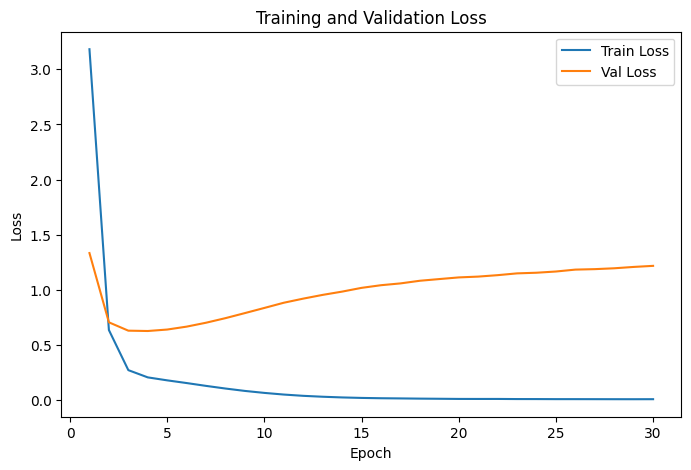

In [31]:
import matplotlib.pyplot as plt

epochs = range(1, lstm_num_epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, lstm_train_losses, label="Train Loss")
plt.plot(epochs, lstm_val_losses, label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.legend()

plt.show()

# Реализация и обучение GRU

In [32]:
vocab_size = word_tokenizer.vocab_size
print(vocab_size)

model_GRU = NextWord(vocab_size=vocab_size, embedding_dim=128, hidden_dim=256, num_layers=2, rnn_type='GRU')
# model_GRU = NextWord(vocab_size=vocab_size, embedding_dim=128, hidden_dim=256, num_layers=2, rnn_type='LSTM')

model_GRU = model_GRU.to(device)

criterion = nn.CrossEntropyLoss(ignore_index=-100)

optimizer = torch.optim.Adam(model_GRU.parameters(), lr=0.001)

print(model_GRU)

18386
NextWord(
  (embedding): Embedding(18386, 128)
  (rnn): GRU(128, 256, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=512, out_features=18386, bias=True)
)


In [33]:
import time
import math

gru_num_epochs = 30
# gru_num_epochs = 8

gru_train_losses = []
gru_val_losses = []
gru_val_ppls = []

gru_epoch_times = []

for epoch in range(gru_num_epochs):

    start_time = time.time()

    # TRAIN
    model_GRU.train()

    total_train_loss = 0

    for x_batch, y_batch in tqdm(train_dataloader):

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model_GRU(x_batch)

        # потеря по последним словам батча
        # last_logits = logits[:, -1, :]
        # last_targets = y_batch[:, -1]

        # loss = criterion(
        #     last_logits,
        #     last_targets
        # )

        # потеря по всем словам последовательности 
        loss = criterion(
            logits.reshape(-1, vocab_size),
            y_batch.reshape(-1)
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model_GRU.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_dataloader)

    # VALIDATION
    model_GRU.eval()

    total_val_loss = 0

    with torch.no_grad():

        for x_batch, y_batch in tqdm(val_dataloader):

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model_GRU(x_batch)

            # if id == 0 and epoch == 4:
            #     print(f'x_batch {word_tokenizer.decode(x_batch[0].tolist())}')
            #     print(f'y_batch {word_tokenizer.decode(y_batch[0].tolist())}')
            #     temp = torch.argmax(logits[0], dim=1)
            #     print(f'logits {word_tokenizer.decode(temp.tolist())}')
            #     print('*' * 40)

            # потеря по последним словам батча
            # last_logits = logits[:, -1, :]
            # last_targets = y_batch[:, -1]

            # loss = criterion(
            #     last_logits,
            #     last_targets
            # )

            # потеря по всем словам последовательности
            loss = criterion(
                logits.reshape(-1, vocab_size),
                y_batch.reshape(-1)
            )

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_dataloader)

    # perplexity
    perplexity = math.exp(avg_val_loss)

    epoch_time = time.time() - start_time

    gru_train_losses.append(avg_train_loss)
    gru_val_losses.append(avg_val_loss)
    gru_val_ppls.append(perplexity)

    gru_epoch_times.append(epoch_time)

    print(
        f"Epoch {epoch+1}/{gru_num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val PPL: {perplexity:.2f} | "
        f"Time: {epoch_time:.2f}s"
    )

fit_gru_time = sum(gru_epoch_times)
avg_gru_epoch_time = sum(gru_epoch_times) / len(gru_epoch_times)
print("Total GRU time:", fit_gru_time)
print("Average GRU epoch time:", avg_gru_epoch_time)

100%|██████████| 436/436 [00:01<00:00, 288.49it/s]


Epoch 1/30 | Train Loss: 1.9282 | Val Loss: 0.7257 | Val PPL: 2.07 | Time: 32.88s


100%|██████████| 436/436 [00:01<00:00, 288.59it/s]


Epoch 2/30 | Train Loss: 0.2787 | Val Loss: 0.6309 | Val PPL: 1.88 | Time: 32.98s


100%|██████████| 436/436 [00:01<00:00, 289.33it/s]


...

Epoch 28/30 | Train Loss: 0.0167 | Val Loss: 1.1961 | Val PPL: 3.31 | Time: 33.02s


100%|██████████| 436/436 [00:01<00:00, 289.20it/s]


Epoch 29/30 | Train Loss: 0.0170 | Val Loss: 1.1982 | Val PPL: 3.31 | Time: 33.00s


100%|██████████| 436/436 [00:01<00:00, 290.04it/s]

Epoch 30/30 | Train Loss: 0.0171 | Val Loss: 1.2123 | Val PPL: 3.36 | Time: 32.94s
Total GRU time: 989.1006999015808
Average GRU epoch time: 32.97002333005269


In [34]:
model_GRU.eval()

total_test_gru_loss = 0

with torch.no_grad():

    for id, (x_batch, y_batch) in enumerate(test_dataloader):

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model_GRU(x_batch)

        if id == 0 and epoch == 4:
            print(f'x_batch {word_tokenizer.decode(x_batch[0].tolist())}')
            print(f'y_batch {word_tokenizer.decode(y_batch[0].tolist())}')
            temp = torch.argmax(logits[0], dim=1)
            print(f'logits {word_tokenizer.decode(temp.tolist())}')
            print('*' * 40)

        # потеря по последним словам батча
        # last_logits = logits[:, -1, :]
        # last_targets = y_batch[:, -1]

        # loss = criterion(
        #     last_logits,
        #     last_targets
        # )                     

        # потеря по всем словам последовательности
        loss = criterion(
            logits.reshape(-1, vocab_size),
            y_batch.reshape(-1)
        )

        total_test_gru_loss += loss.item()

avg_test_gru_loss = total_test_gru_loss / len(test_dataloader)

# perplexity
test_gru_perplexity = math.exp(avg_test_gru_loss)
print(f"Test PPL: {test_gru_perplexity:.2f}")

Test PPL: 3.37


## Сохранение модели GRU

In [35]:
from datetime import datetime
import torch

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

model_path = f"next_word_gru_{timestamp}.pth"

torch.save(model_GRU.state_dict(), model_path)

print(f"Model saved to: {model_path}")

Model saved to: next_word_gru_20260518_124404.pth


## Графики обучения GRU

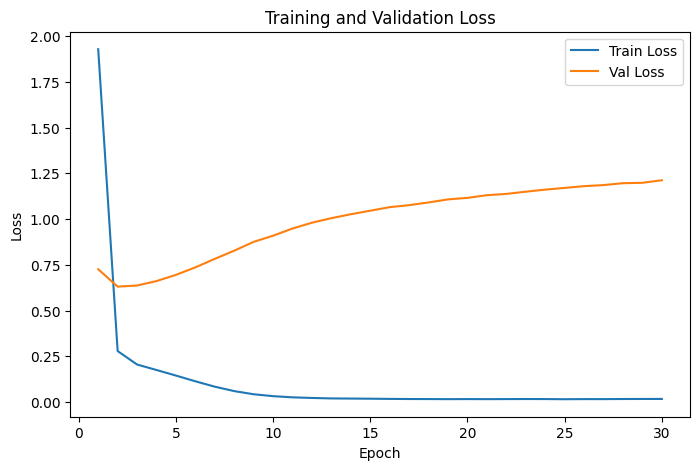

In [36]:
import matplotlib.pyplot as plt

epochs = range(1, gru_num_epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, gru_train_losses, label="Train Loss")
plt.plot(epochs, gru_val_losses, label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.legend()

plt.show()

# Эксперимент: GRU vs LSTM

## Сравнение loss

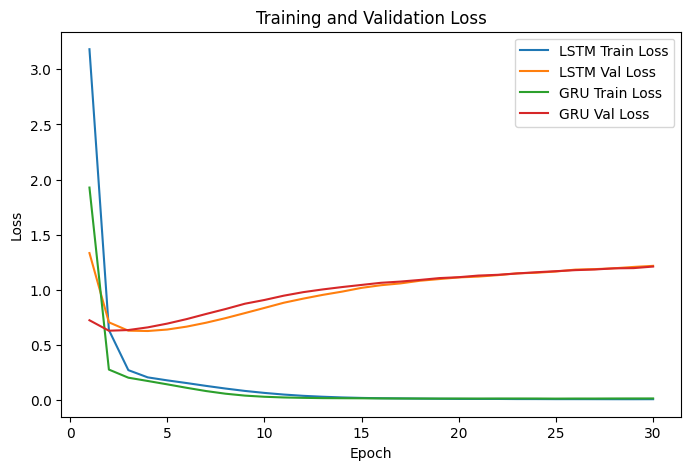

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(range(1, lstm_num_epochs + 1), lstm_train_losses, label="LSTM Train Loss")
plt.plot(range(1, lstm_num_epochs + 1), lstm_val_losses, label="LSTM Val Loss")

plt.plot(range(1, gru_num_epochs + 1), gru_train_losses, label="GRU Train Loss")
plt.plot(range(1, gru_num_epochs + 1), gru_val_losses, label="GRU Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.legend()

plt.show()

## Сравнение perplexity

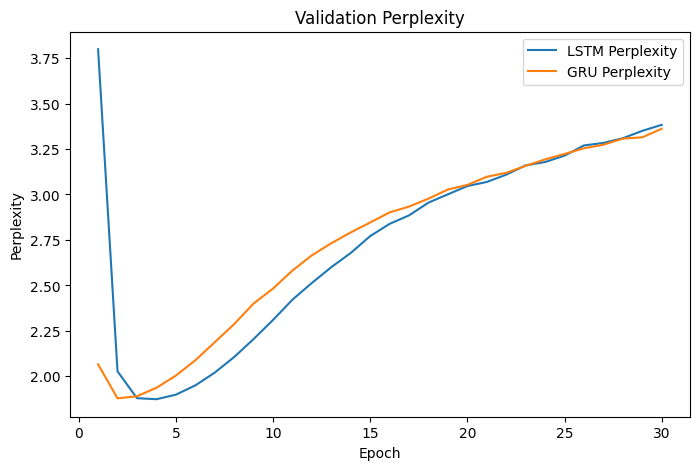

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, lstm_num_epochs + 1), lstm_val_ppls, label="LSTM Perplexity")

plt.plot(range(1, gru_num_epochs + 1), gru_val_ppls, label="GRU Perplexity")

plt.xlabel("Epoch")
plt.ylabel("Perplexity")

plt.title("Validation Perplexity")

plt.legend()

plt.show()

## Сравнение epoch time

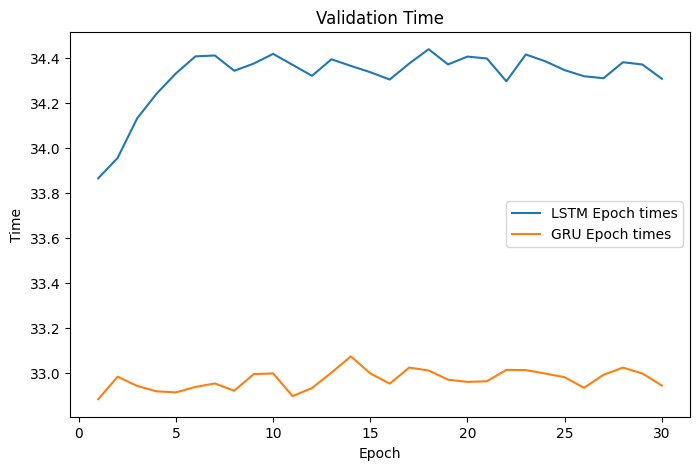

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, lstm_num_epochs + 1), lstm_epoch_times, label="LSTM Epoch times")
plt.plot(range(1, lstm_num_epochs + 1), gru_epoch_times, label="GRU Epoch times")

plt.xlabel("Epoch")
plt.ylabel("Time")

plt.title("Validation Time")

plt.legend()

plt.show()

## Количество параметров

In [40]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

lstm_params = count_parameters(model_LSTM)
gru_params = count_parameters(model_GRU)

print("LSTM params:", lstm_params)
print("GRU params :", gru_params)

LSTM params: 14152914
GRU params : 13561042


# Выводы по эксперименту

GRU показала более быстрое обучение и меньшее количество параметров по сравнению с LSTM при одинаковых гиперпараметрах.
LSTM достигла немного лучшего значения perplexity, однако разница в качестве оказалась небольшой.
Для данной задачи GRU является более вычислительно эффективной моделью, тогда как LSTM может быть предпочтительнее при необходимости моделирования более длинных зависимостей.

Как видно по предсказания, модель хорошо обучается на датасете, но данные в нем очень однообразные. 

# Предобученный трансформер: distilgpt2

## Загрузка предобученной модели distilgpt2 и его токенизатора

In [41]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

model_name = "distilgpt2"
tokenizer = GPT2TokenizerFast.from_pretrained(model_name)
gpt2_model = GPT2LMHeadModel.from_pretrained(model_name) 


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

In [42]:
tokenizer.pad_token = tokenizer.eos_token

gpt2_model = gpt2_model.to(device)

gpt2_model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

# Вычисление perplexity distilgpt2 на тестовой выборке

## Подготовка тестовой выборки

In [43]:
class TextDataset(Dataset):
    def __init__(self, texts, tokenizer, seq_len=32, max_length=512):
        self.samples = []
        
        for text in texts:
            tokens = tokenizer.encode(text, truncation=True, max_length=max_length)

            if len(tokens) < seq_len:
                continue

            for i in range(0, len(tokens) - seq_len + 1, seq_len):
                seq = tokens[i:i + seq_len]

                context = seq[:-1]
                target = seq[1:]

                self.samples.append((torch.tensor(context), torch.tensor(target)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def collate_fn(batch):
    x_batch, y_batch = zip(*batch)

    x_padded = pad_sequence(x_batch, batch_first=True, padding_value=tokenizer.pad_token_id)
    attention_mask = (x_padded != tokenizer.pad_token_id).long()
    y_padded = pad_sequence(y_batch, batch_first=True, padding_value=-100)

    return x_padded, y_padded, attention_mask

In [44]:
gpt_val_dataset = TextDataset(val_corpus, tokenizer=tokenizer)
gpt_test_dataset = TextDataset(test_corpus, tokenizer=tokenizer)

gpt_val_dataloader = DataLoader(gpt_val_dataset, batch_size=batch_size, collate_fn=collate_fn,)
gpt_test_dataloader = DataLoader(gpt_test_dataset, batch_size=batch_size, collate_fn=collate_fn,)

print(f'Количество батчей в test_dataloader: {len(test_dataloader)}')

x_batch, y_batch, attention_mask = next(iter(gpt_test_dataloader))

print("\nX shape:", x_batch.shape)
print("Y shape:", y_batch.shape)

print("\nX example:")
print(x_batch[0])

print("\nY example:")
print(y_batch[0])

print("\nDecoded X:")
print(tokenizer.decode(x_batch[0].tolist()))

print("\nDecoded Y:")
print(tokenizer.decode(
    y_batch[0][y_batch[0] != -100].tolist()
))


Количество батчей в test_dataloader: 425

X shape: torch.Size([32, 31])
Y shape: torch.Size([32, 31])

X example:
tensor([13528,  4223,   261,   468,   587,  1363,   284,   867,  1593,  5538,
          287, 48659,   292,   290,   514,  2106,  1141,   262,  7022,   264,
        14555,  2106,   340,  2627,   262,  7386,   286,   474, 11025,   300,
         1878])

Y example:
tensor([ 4223,   261,   468,   587,  1363,   284,   867,  1593,  5538,   287,
        48659,   292,   290,   514,  2106,  1141,   262,  7022,   264, 14555,
         2106,   340,  2627,   262,  7386,   286,   474, 11025,   300,  1878,
         2654])

Decoded X:
galveston has been home to many important figures in texas and us history during the island s earliest history it became the domain of jean laf

Decoded Y:
veston has been home to many important figures in texas and us history during the island s earliest history it became the domain of jean lafitte


## Вычисление perplexity на тестовой выборке

In [45]:
total_val_loss = 0

with torch.no_grad():

    for x_batch, y_batch, attention_mask in tqdm(gpt_val_dataloader):
        x_batch = x_batch.to(device)
        # y_batch = y_batch.to(device)
        attention_mask = attention_mask.to(device)
        labels = x_batch.clone()
        labels[labels == tokenizer.pad_token_id] = -100

        # outputs = gpt2_model(input_ids=x_batch, attention_mask=attention_mask, labels=x_batch)
        outputs = gpt2_model(input_ids=x_batch, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss
        total_val_loss += loss.item()

avg_gpt_val_loss = total_val_loss / len(gpt_val_dataloader)

# perplexity
gpt_val_perplexity = math.exp(avg_gpt_val_loss)

print(
    f"Test Loss: {avg_gpt_val_loss:.4f} | "
    f"Test PPL: {gpt_val_perplexity:.2f}"
)

100%|██████████| 178/178 [00:09<00:00, 19.30it/s]

Test Loss: 5.8697 | Test PPL: 354.14


In [46]:
total_test_loss = 0

with torch.no_grad():

    for x_batch, y_batch, attention_mask in tqdm(gpt_test_dataloader):

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = gpt2_model(input_ids=x_batch, attention_mask=attention_mask, labels=x_batch)

        loss = outputs.loss
        total_test_loss += loss.item()

avg_gpt_test_loss = total_test_loss / len(gpt_test_dataloader)

# perplexity
gpt_test_perplexity = math.exp(avg_gpt_test_loss)

print(
    f"Test Loss: {avg_gpt_test_loss:.4f} | "
    f"Test PPL: {gpt_test_perplexity:.2f}"
)

100%|██████████| 174/174 [00:08<00:00, 19.63it/s]

Test Loss: 5.8657 | Test PPL: 352.74


# Получение logits вручную и предсказание следующего токена + rough

In [47]:
text = "The cat sat on"

inputs = tokenizer(text, return_tensors="pt")
input_ids = inputs["input_ids"].to(device)

with torch.no_grad():
    outputs = gpt2_model(input_ids)
    logits = outputs.logits

print('Shape:', logits.shape)

last_token_logits = logits[:, -1, :]

predicted_token_id = torch.argmax(last_token_logits, dim=-1)

predicted_word = tokenizer.decode(predicted_token_id)

print('Predict:', predicted_word.strip())

Shape: torch.Size([1, 4, 50257])
Predict: the


In [48]:
%pip install evaluate

Note: you may need to restart the kernel to use updated packages.


In [49]:
%pip install rouge_score nltk

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.6 MB/s  0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24988 sha256=186586bd7732bb821f89473ed2c7f6ca967373ede17f14d91342de48a5c3d22c
  Stored in directory: /home/ubuntu/.cache/pip/wheels/5f/dd/89/461065a73be61a532ff8599a28e9beef17985c9e9c31e541b4
Successfully built rouge_score
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [rouge_score]
Note: you may need to restart the kernel to use updated packages.


In [50]:
import evaluate
from tqdm import tqdm

rouge = evaluate.load("rouge")

In [51]:
sentences = []

references = []
predictions = []

for i in range(len(test_word)):
    if len(test_word[i]) > 10:
        sentences.append(test_word[i][:10])
    if len(sentences) > 10:
        break

gpt2_model.eval()

for sentence in sentences:

    # убираем последнее слово
    input_text = ' '.join(sentence[:-1])
    references.append(' '.join(sentence[1:]))

    # настоящее последнее слово
    true_last_word = sentence[-1]

    # токенизация
    inputs = tokenizer(input_text, return_tensors="pt")
    input_ids = inputs["input_ids"].to(device)

    # предсказание
    with torch.no_grad():
        outputs = gpt2_model(input_ids)
        logits = outputs.logits

    # logits последнего токена
    last_token_logits = logits[:, -1, :]

    # id предсказанного токена
    predicted_token_id = torch.argmax(last_token_logits, dim=-1)

    # декодирование
    predicted_word = tokenizer.decode(predicted_token_id)
    predictions.append(' '.join(sentence[1:-1]) + ' ' + predicted_word.strip())

    print(f"Текст:      {input_text}")
    print(f"Истинное слово:  {true_last_word}")
    print(f"Предположение:  {predicted_word.strip()}")
    print("-" * 50)

Текст:      galveston has been home to many important figures in
Истинное слово:  texas
Предположение:  the
--------------------------------------------------
Текст:      after ericsson s may 1916 commissioning she sailed off
Истинное слово:  the
Предположение:  the
--------------------------------------------------
Текст:      the post first world war years marked a decline
Истинное слово:  in
Предположение:  in
--------------------------------------------------
Текст:      the fruit body is 1 8 cm 0 4
Истинное слово:  3
Предположение:  .
--------------------------------------------------
Текст:      bill oakley and josh weinstein greatly enjoyed the episode
Истинное слово:  and
Предположение:  .
--------------------------------------------------
Текст:      i miss you aitai a girl has doubts about
Истинное слово:  staying
Предположение:  her
--------------------------------------------------
Текст:      fowler earned his first cap for england on 27
Истинное слово:  march
Предположени

In [52]:
# Подсчёт метрик
results = rouge.compute(predictions=predictions, references=references)
print('Metrics')
for k, v in results.items():
    print(f"{k}: {v:.4f}")

print(references)
print(predictions)

Metrics
rouge1: 0.9335
rouge2: 0.9250
rougeL: 0.9335
rougeLsum: 0.9335
['has been home to many important figures in texas', 'ericsson s may 1916 commissioning she sailed off the', 'post first world war years marked a decline in', 'fruit body is 1 8 cm 0 4 3', 'oakley and josh weinstein greatly enjoyed the episode and', 'miss you aitai a girl has doubts about staying', 'earned his first cap for england on 27 march', 'the late 1980s as many as 32 subspecies were', 'ancient city of sarapion is believed to have been', 'april 9 2009 the united states postal service unveiled', 'a xenon oxygen mixture activates production of the transcription']
['has been home to many important figures in the', 'ericsson s may 1916 commissioning she sailed off the', 'post first world war years marked a decline in', 'fruit body is 1 8 cm 0 4 .', 'oakley and josh weinstein greatly enjoyed the episode .', 'miss you aitai a girl has doubts about her', 'earned his first cap for england on 27 -', 'the late 1980s as

# Сравнение и выводы

## Сводная таблица результатов

In [53]:
import pandas as pd

# данные
data = {
    "Модель": ["LSTM", "GRU", "GPT2"],
    "params": [count_parameters(model_LSTM), count_parameters(model_GRU), count_parameters(gpt2_model)],
    "best epoch": [lstm_val_losses.index(min(lstm_val_losses)), gru_val_losses.index(min(gru_val_losses)), pd.NA],
    "total epoch": [lstm_num_epochs, gru_num_epochs, pd.NA],
    "fit time": [fit_lstm_time, fit_gru_time, pd.NA],
    "mean epoch time": [avg_lstm_epoch_time, avg_gru_epoch_time, pd.NA],
    "val ppl": [min(lstm_val_ppls), min(gru_val_ppls), gpt_val_perplexity],
    "val loss": [min(lstm_val_losses), min(gru_val_losses), avg_gpt_val_loss],
    "test ppl": [test_lstm_perplexity, test_gru_perplexity, gpt_test_perplexity],
    "test loss": [avg_test_lstm_loss, avg_test_gru_loss, avg_gpt_test_loss],
}

# создание таблицы
df = pd.DataFrame(data)

# вывод таблицы
df

,Модель,params,best epoch,total epoch,fit time,mean epoch time,val ppl,val loss,test ppl,test loss
0,LSTM,14152914,3,30,1029.684983,34.322833,1.874297,0.628233,3.348729,1.208581
1,GRU,13561042,1,30,989.1007,32.970023,1.879273,0.630885,3.368607,1.214499
2,GPT2,81912576,<NA>,<NA>,<NA>,<NA>,354.140395,5.869693,352.743702,5.865742


## Примеры предсказаний всех моделей на одних и тех же контекстах + rough

In [54]:
sentences = []

references = []
predictions = []

for i in range(len(test_word)):
    if len(test_word[i]) > 10:
        sentences.append(test_word[i][:10])
    if len(sentences) > 10:
        break

model_LSTM.eval()

for id, sentence in enumerate(sentences):

    # разбиваем предложение на слова
    words = sentence[:-1]
    references.append(' '.join(sentence[1:]))

    # настоящее последнее слово
    true_last_word = sentence[-1]

    # # токенизация
    inputs = word_tokenizer.encode(words)
    input_tokens = torch.tensor(inputs).unsqueeze(0).to(device)

    # предсказание
    with torch.no_grad():
        logits = model_LSTM(input_tokens)

    # temp = torch.argmax(logits[0], dim=1)
    # print(f'logits {word_tokenizer.decode(temp.tolist())}')

    # logits последнего токена
    last_token_logits = logits[:, -1, :]

    # id предсказанного токена
    predicted_token_id = torch.argmax(last_token_logits, dim=-1).item()

    # декодирование
    predicted_word = word_tokenizer.decode([predicted_token_id])
    predictions.append(' '.join(sentence[1:-1]) + ' ' + predicted_word[0])

    print(f"Строка:     {id}")
    print(f"Текст:      {words}")
    print(f"Истинное слово:  {true_last_word}")
    print(f"Предположение:  {predicted_word}")
    print("-*" * 50)

Строка:     0
Текст:      ['galveston', 'has', 'been', 'home', 'to', 'many', 'important', 'figures', 'in']
Истинное слово:  texas
Предположение:  ['this']
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Строка:     1
Текст:      ['after', 'ericsson', 's', 'may', '1916', 'commissioning', 'she', 'sailed', 'off']
Истинное слово:  the
Предположение:  ['in']
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Строка:     2
Текст:      ['the', 'post', 'first', 'world', 'war', 'years', 'marked', 'a', 'decline']
Истинное слово:  in
Предположение:  ['that']
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Строка:     3
Текст:      ['the', 'fruit', 'body', 'is', '1', '8', 'cm', '0', '4']
Истинное слово:  3
Предположение:  ['to']
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Строка:     4
Те

In [55]:
# Подсчёт метрик
results = rouge.compute(predictions=predictions, references=references)
print('Metrics')
for k, v in results.items():
    print(f"{k}: {v:.4f}")

print(references)
print(predictions)

Metrics
rouge1: 0.8990
rouge2: 0.8864
rougeL: 0.8990
rougeLsum: 0.8990
['has been home to many important figures in texas', 'ericsson s may 1916 commissioning she sailed off the', 'post first world war years marked a decline in', 'fruit body is 1 8 cm 0 4 3', 'oakley and josh weinstein greatly enjoyed the episode and', 'miss you aitai a girl has doubts about staying', 'earned his first cap for england on 27 march', 'the late 1980s as many as 32 subspecies were', 'ancient city of sarapion is believed to have been', 'april 9 2009 the united states postal service unveiled', 'a xenon oxygen mixture activates production of the transcription']
['has been home to many important figures in this', 'ericsson s may 1916 commissioning she sailed off in', 'post first world war years marked a decline that', 'fruit body is 1 8 cm 0 4 to', 'oakley and josh weinstein greatly enjoyed the episode earned', 'miss you aitai a girl has doubts about 2', 'earned his first cap for england on 27 april', 'the lat

In [56]:
sentences = []

references = []
predictions = []

for i in range(len(test_word)):
    if len(test_word[i]) > 10:
        sentences.append(test_word[i][:10])
    if len(sentences) > 10:
        break

model_GRU.eval()

for sentence in sentences:

    # разбиваем предложение на слова
    words = sentence[:-1]
    references.append(' '.join(sentence[1:]))

    # настоящее последнее слово
    true_last_word = sentence[-1]

    # # токенизация
    inputs = word_tokenizer.encode(words)
    input_tokens = torch.tensor(inputs).unsqueeze(0).to(device)

    # предсказание
    with torch.no_grad():
        logits = model_GRU(input_tokens)
    
    # temp = torch.argmax(logits[0], dim=1)
    # print(f'logits {word_tokenizer.decode(temp.tolist())}')

    # logits последнего токена
    last_token_logits = logits[:, -1, :]

    # id предсказанного токена
    predicted_token_id = torch.argmax(last_token_logits, dim=-1).item()
    print(predicted_token_id)

    # декодирование
    predicted_word = word_tokenizer.decode([predicted_token_id])
    predictions.append(' '.join(sentence[1:-1]) + ' ' + predicted_word[0])

    print(f"Строка:     {id}")
    print(f"Текст:      {words}")
    print(f"Истинное слово:  {true_last_word}")
    print(f"Предположение:  {predicted_word}")
    print("-*" * 50)

696
Строка:     10
Текст:      ['galveston', 'has', 'been', 'home', 'to', 'many', 'important', 'figures', 'in']
Истинное слово:  texas
Предположение:  ['different']
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
8
Строка:     10
Текст:      ['after', 'ericsson', 's', 'may', '1916', 'commissioning', 'she', 'sailed', 'off']
Истинное слово:  the
Предположение:  ['the']
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
22
Строка:     10
Текст:      ['the', 'post', 'first', 'world', 'war', 'years', 'marked', 'a', 'decline']
Истинное слово:  in
Предположение:  ['in']
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
48
Строка:     10
Текст:      ['the', 'fruit', 'body', 'is', '1', '8', 'cm', '0', '4']
Истинное слово:  3
Предположение:  ['1']
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*

In [57]:
# Подсчёт метрик
results = rouge.compute(predictions=predictions, references=references)
print('Metrics')
for k, v in results.items():
    print(f"{k}: {v:.4f}")

print(references)
print(predictions)

Metrics
rouge1: 0.9192
rouge2: 0.9091
rougeL: 0.9192
rougeLsum: 0.9192
['has been home to many important figures in texas', 'ericsson s may 1916 commissioning she sailed off the', 'post first world war years marked a decline in', 'fruit body is 1 8 cm 0 4 3', 'oakley and josh weinstein greatly enjoyed the episode and', 'miss you aitai a girl has doubts about staying', 'earned his first cap for england on 27 march', 'the late 1980s as many as 32 subspecies were', 'ancient city of sarapion is believed to have been', 'april 9 2009 the united states postal service unveiled', 'a xenon oxygen mixture activates production of the transcription']
['has been home to many important figures in different', 'ericsson s may 1916 commissioning she sailed off the', 'post first world war years marked a decline in', 'fruit body is 1 8 cm 0 4 1', 'oakley and josh weinstein greatly enjoyed the episode was', 'miss you aitai a girl has doubts about various', 'earned his first cap for england on 27 release', 

# Выводы: какая модель лучше и почему. Дайте рекомендации для продакт-менеджера

### В задаче предсказания следующего слова модели LSTM и GRU показывают схожие результаты, однако выбор между ними зависит от требований проекта. GRU обычно обучается быстрее, использует меньше памяти и обеспечивает более низкую задержку при inference, поэтому она хорошо подходит для MVP, production-систем и задач с ограниченными вычислительными ресурсами. LSTM имеет более сложную архитектуру и лучше справляется с сохранением долгосрочного контекста, что может давать более высокое качество на больших датасетах и длинных текстах. На практике разница в качестве между моделями часто оказывается небольшой, поэтому для большинства прикладных решений рекомендуется начинать с GRU как более дешёвого и эффективного варианта, а LSTM использовать в случаях, когда дополнительное улучшение качества действительно критично для бизнеса и оправдывает увеличение вычислительных затрат.